In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
ELLIPSE_ROOT = ANALYSIS_ROOT / 'ellipse_tilt_analysis'
for path in (ANALYSIS_ROOT, CASE_ROOT, FLOW_ROOT, ELLIPSE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
import ellipse_tilt_tools as et

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
#############################################
# df_eddies, _ = tilt.load_tilt_tables(paths)
# df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
CACHE_ROOT = Path(
    "/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/"
    "pv_gradient_depth_following"
)
SNAPSHOT_PATH = (
    CACHE_ROOT / "pv_gradient_depth_following_snapshot_0_1000m.parquet"
)
df_eddies = pd.read_parquet(SNAPSHOT_PATH)
#############################################
df_eddies = tilt.add_region_labels(df_eddies, grid)


# Surface ellipse geometry and axial tilt alignment (0° parallel, 90° perpendicular).
df_eddies = et.ellipse_geometry(df_eddies)
df_eddies['TiltMajorAlignmentDeg'] = np.abs(
    et.axial_difference(df_eddies.TiltDir, df_eddies.MajorBearing)
)

# Primary environmental shear used in the background-flow analysis:
# centred seasonal climatology, surface minus the 200–500 m layer mean.
background = load_background_cache(BackgroundConfig()).drop(
    columns=['ic', 'jc'], errors='ignore'
)
needed = {'clim_surface_east_ms', 'clim_surface_north_ms',
          'clim_200_east_ms', 'clim_200_north_ms',
          'clim_500_east_ms', 'clim_500_north_ms'}
missing = needed - set(background.columns)
if missing:
    raise RuntimeError(f'Background cache is missing {sorted(missing)}')
df_eddies = df_eddies.merge(
    background[['Eddy', 'Day', *sorted(needed)]],
    on=['Eddy', 'Day'], how='left', validate='one_to_one'
)
for component in ('east', 'north'):
    deep = (500 * df_eddies[f'clim_500_{component}_ms']
            - 200 * df_eddies[f'clim_200_{component}_ms']) / 300
    df_eddies[f'clim_upper_minus_deep_{component}_ms'] = (
        df_eddies[f'clim_200_{component}_ms'] - deep
    )
SHEAR_E = 'clim_upper_minus_deep_east_ms'
SHEAR_N = 'clim_upper_minus_deep_north_ms'


In [3]:
oldest = (df_eddies.groupby(['Cyc','Eddy']).Age.first()
          .groupby('Cyc').nlargest(10).index.get_level_values('Eddy'))

df_old = df_eddies[df_eddies.Eddy.isin(oldest)].copy()

(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

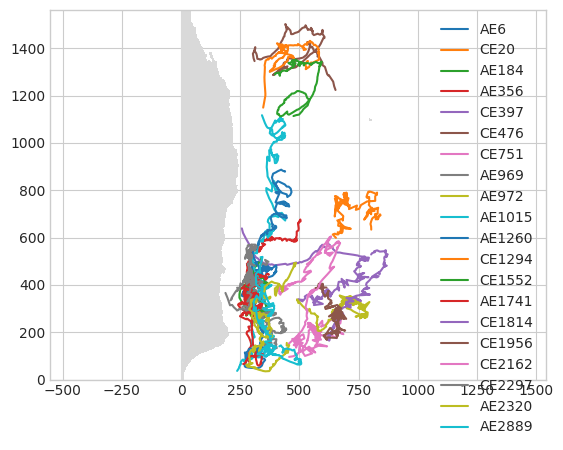

In [4]:
plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, np.nan,0))
for eddy in df_old.Eddy.unique():
    df = df_old[df_old.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=f'{df.iloc[0].Cyc}{eddy}')
plt.legend()
plt.axis('equal')

In [5]:
def time_plot(eddy, df_data, grid=grid, figsize=(13, 10), hspace=0.08):

    df = df_data[df_data.Eddy.eq(eddy)].sort_values('Day').copy()
    if df.empty:
        raise ValueError(f'Eddy {eddy} is not present in df_data')
    t = df.Day - df.Day.iloc[0]
    cyc = df.Cyc.iloc[0]

    # ---------------- colours ----------------
    c = {
        'tilt'   : 'tab:purple',
        'pvgrad' : 'tab:green',
        'ratio'  : 'tab:orange',
        'ratio_s': 'tab:red',
        'ro'     : 'tab:olive',
        'pv'     : 'tab:blue',
        'h'      : 'tab:brown',
        'beta'   : 'tab:cyan',
        'avort'  : 'tab:pink',
        'dtheta' : 'k',
        'east'   : 'tab:red',
        'north'  : 'tab:blue',
        'align'  : 'tab:purple',
        'shape'  : 'tab:brown',
    }

    # Assuming log(|beta_topo| / |beta_plan|)
    threshold = np.log(2)
    planetary = df.topo_plan_ratio_smooth <= -threshold
    topographic = df.topo_plan_ratio_smooth >= threshold
    PLAN_COLOR = 'tab:green'
    TOPO_COLOR = 'tab:orange'

    # PV-gradient alignment criterion
    # aligned = (df.dtheta_PV_grad < 45) if cyc == 'AE' else (df.dtheta_PV_grad > 135)

    # ---------------- figure ----------------
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(9, 2, width_ratios=[2.2, 1], hspace=hspace)

    axs = [fig.add_subplot(gs[i, 0]) for i in range(9)]
    axm = fig.add_subplot(gs[:, 1])

    # Shade topo / planetary dominated periods
    for ax in axs:
        for i in np.where(planetary)[0]:
            ax.axvspan(t.iloc[i]-.5, t.iloc[i]+.5,
                       color=PLAN_COLOR, alpha=.2, lw=0)

        for i in np.where(topographic)[0]:
            ax.axvspan(t.iloc[i]-.5, t.iloc[i]+.5,
                       color=TOPO_COLOR, alpha=.2, lw=0)
    

    # =========================================================
    # 1. Tilt magnitude + PV-gradient magnitude
    # =========================================================
    axs[0].plot(t, df.TiltDis, color=c['tilt'], lw=1.7)
    axs[0].set_ylabel('Tilt distance [km]', color=c['tilt'])
    axs[0].tick_params(axis='y', labelcolor=c['tilt'])

    ax0 = axs[0].twinx()
    ax0.plot(t, df.PV_grad_mag, color=c['pvgrad'], lw=1.3, alpha=.8)
    ax0.set_ylabel(r'$|\nabla PV|$', color=c['pvgrad'])
    ax0.tick_params(axis='y', labelcolor=c['pvgrad'])

    # =========================================================
    # 2. Topographic / planetary dominance
    # =========================================================
    axs[1].plot(t, df.topo_plan_ratio,
                color=c['ratio'], alpha=.3, lw=1)

    axs[1].plot(t, df.topo_plan_ratio_smooth,
                color=c['ratio_s'], lw=1.7)

    axs[1].axhline(0, color='0.2', ls='-', lw=.8)
    axs[1].axhline(np.log(2), color=TOPO_COLOR, ls='--', lw=.8, label='topo')
    axs[1].axhline(-np.log(2), color=PLAN_COLOR, ls='--', lw=.8, label='plan')
    axs[1].legend(ncol=2, loc='lower center')
    axs[1].set_ylabel(
        r'$\ln(|\nabla PV|_{\mathrm{topo}}/'
        r'|\nabla PV|_{\mathrm{plan}})$'
    )
    axs[1].tick_params(axis='y', labelcolor=c['ratio_s'])

    # =========================================================
    # 3. Eddy dynamical strength
    # =========================================================
    axs[2].plot(t, df.Ro, color=c['ro'], lw=1.7)
    axs[2].set_ylabel(r'$Ro$', color=c['ro'])
    axs[2].tick_params(axis='y', labelcolor=c['ro'])

    # =========================================================
    # 4. PV + depth
    # =========================================================
    axs[3].plot(t, df.PV, color=c['pv'], lw=1.7)
    axs[3].set_ylabel('PV', color=c['pv'])
    axs[3].tick_params(axis='y', labelcolor=c['pv'])

    ax3 = axs[3].twinx()
    ax3.plot(t, df.h/1e3, color=c['h'], lw=1.3, alpha=.8)
    ax3.set_ylabel('Depth [km]', color=c['h'])
    ax3.tick_params(axis='y', labelcolor=c['h'])
    ax3.invert_yaxis()

    # =========================================================
    # 5. Background beta + absolute vorticity
    # =========================================================
    # axs[4].plot(t, df.beta, color=c['beta'], lw=1.7)
    # axs[4].set_ylabel(r'$\beta$', color=c['beta'])
    # axs[4].tick_params(axis='y', labelcolor=c['beta'])
    
    axs[4].plot(t, df.w, color=c['beta'], lw=1.7)
    axs[4].set_ylabel(r'$\zeta$', color=c['beta'])
    
    ax4 = axs[4].twinx()
    ax4.plot(t, df.f, color=c['avort'], lw=1.3)
    ax4.set_ylabel(r'$f$', color=c['avort'])
    ax4.tick_params(axis='y', labelcolor=c['avort'])

    # =========================================================
    # 6. Eastward and northward tilt components
    # =========================================================
    tilt_theta = np.deg2rad(df.TiltDir)
    axs[5].plot(t, df.TiltDis*np.sin(tilt_theta),
                color=c['east'], lw=1.5, label='Zonal')
    axs[5].plot(t, df.TiltDis*np.cos(tilt_theta),
                color=c['north'], lw=1.5, label='Meridional')
    axs[5].axhline(0, color='0.3', lw=.8)
    axs[5].set_ylabel('Tilt [km]')
    axs[5].legend(ncol=2, frameon=False)

    # =========================================================
    # 7. Climatological surface-minus-deep vertical shear
    # =========================================================
    axs[6].plot(t, df[SHEAR_E], color=c['east'], lw=1.5, label='Zonal')
    axs[6].plot(t, df[SHEAR_N], color=c['north'], lw=1.5, label='Meridional')
    axs[6].axhline(0, color='0.3', lw=.8)
    axs[6].set_ylabel('Shear\n[m s$^{-1}$]')
    axs[6].legend(ncol=2, frameon=False)

    # =========================================================
    # 8. Tilt alignment with the surface ellipse major axis
    # =========================================================

    reliable = df.AxisRatio >= 1.1
    y = df.TiltMajorAlignmentDeg
    axs[7].plot(
        t, y.where(reliable),
        color=c['align'], lw=1.5
    )
    axs[7].plot(
        t, y,
        color=c['align'], lw=1.5, alpha=.2
    )
    
    axs[7].axhspan(0, 22.5, color='tab:green', alpha=.15)
    axs[7].set(ylabel='Tilt–major-axis [°]', ylim=(0, 90))
    ax7 = axs[7].twinx()
    ax7.plot(t, df.AxisRatio, color=c['shape'], lw=1.2, alpha=.8)
    ax7.axhline(1.1, color=c['shape'], ls='--', lw=.8)
    ax7.set_ylabel('Axis ratio', color=c['shape'])
    ax7.tick_params(axis='y', labelcolor=c['shape'])

    # =========================================================
    # 9. Tilt / PV-gradient alignment
    # =========================================================
    axs[8].plot(t, df.dtheta_PV_grad,
                color=c['dtheta'], lw=1.5)

    if cyc == 'AE':
        axs[8].axhspan(0, 45, color='tab:green', alpha=.2)
    else:
        axs[8].axhspan(135, 180, color='tab:green', alpha=.2)

    axs[8].set(
        xlabel='Eddy age [days]',
        ylabel=r'$\Delta\theta$ [°]',
        ylim=(0, 180)
    )

    # ---------------- cosmetics ----------------
    for ax in axs:
        ax.grid(alpha=.2)
        ax.margins(x=0)

    # =========================================================
    # MAP
    # =========================================================
    th = np.deg2rad(df.TiltDir)

    xb = df.xc - df.TiltDis*np.sin(th)
    yb = df.yc - df.TiltDis*np.cos(th)

    pad = 20
    xmin = min(df.xc.min(), xb.min()) - pad
    xmax = max(df.xc.max(), xb.max()) + pad
    ymin = min(df.yc.min(), yb.min()) - pad
    ymax = max(df.yc.max(), yb.max()) + pad

    ii = (
        (grid.X_grid >= xmin) & (grid.X_grid <= xmax) &
        (grid.Y_grid >= ymin) & (grid.Y_grid <= ymax)
    )

    bathy = np.where(
        (grid.mask_rho == 1) & ii,
        grid.h / 1e3,
        np.nan
    )

    cf = axm.contourf(
        grid.X_grid, grid.Y_grid, bathy,
        cmap='Greys_r'
    )

    cbar_h = fig.colorbar(
        cf, ax=axm,
        orientation='horizontal',
        location='bottom',
        label='Depth [km]',
        shrink=.8,
        pad=.08
    )
    
    # Surface-centre trajectory coloured by eddy age
    x, y = df.xc.to_numpy(), df.yc.to_numpy()
    age = t.to_numpy()
    
    points = np.column_stack([x, y])
    segments = np.stack([points[:-1], points[1:]], axis=1)
    
    norm = Normalize(age.min(), age.max())
    
    # AE = red, CE = blue
    base = plt.cm.Reds if cyc == 'AE' else plt.cm.Blues
    cmap = LinearSegmentedColormap.from_list(
        'eddy_age', base(np.linspace(.25, .9, 256))
    )
    
    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidth=2
    )
    lc.set_array((age[:-1] + age[1:]) / 2)
    
    axm.add_collection(lc)
    
    cbar_age = fig.colorbar(
        lc, ax=axm,
        orientation='horizontal',
        location='top',
        label='Eddy age [days]',
        shrink=.8,
        pad=.08
    )

    # Surface-to-bottom displacement
    for xs, ys, xbot, ybot, plan, topo in zip(
        df.xc, df.yc, xb, yb, planetary, topographic
    ):
        if plan:
            color=PLAN_COLOR
        elif topo:
            color=TOPO_COLOR
        else:
            color='k'
        
        axm.plot(
            [xs, xbot],
            [ys, ybot],
            color=color,
            alpha=.35,
            lw=1
        )

    axm.set(
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        xlabel='x [km]',
        ylabel='y [km]',
        title= f'{cyc}{eddy}'
    )

    axm.set_aspect('equal')
    # axm.legend(frameon=False)

    for ax in axs[:-1]:
        ax.set_xticklabels([])

    plt.tight_layout()
    plt.show()

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


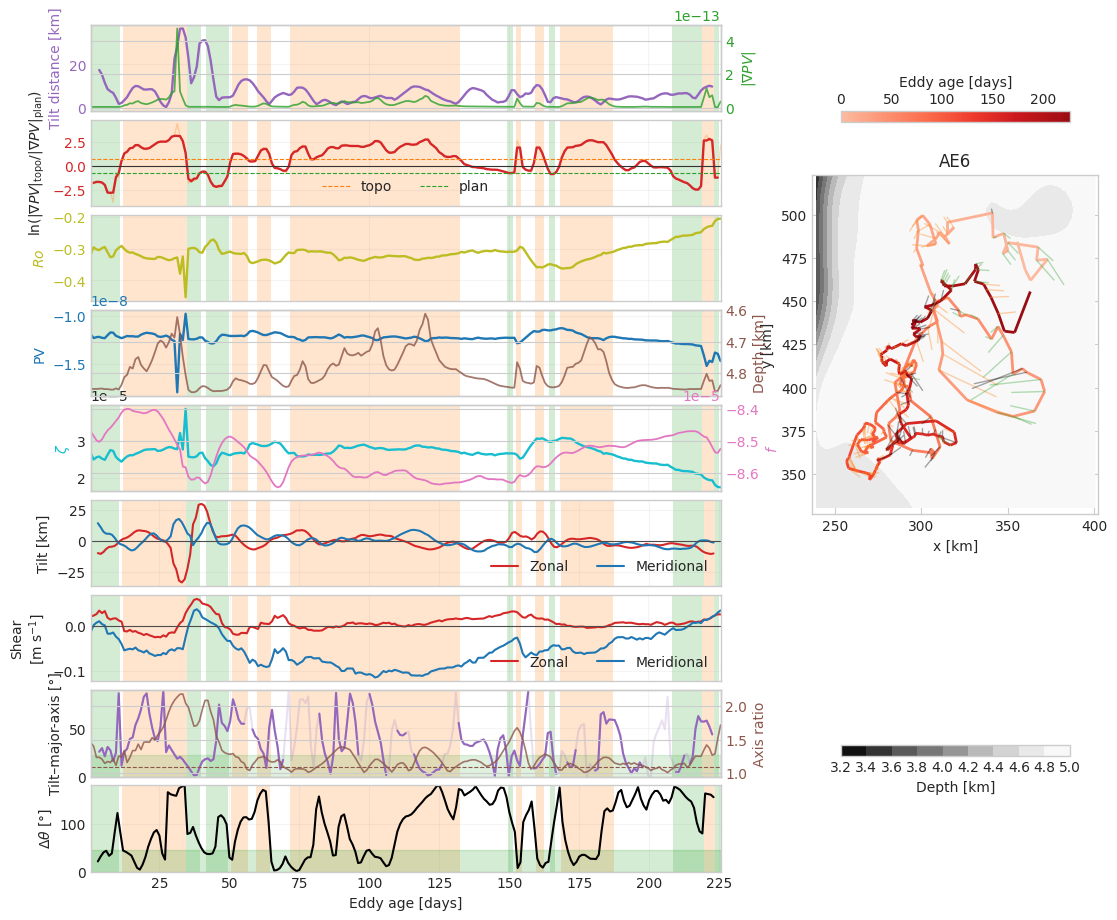

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


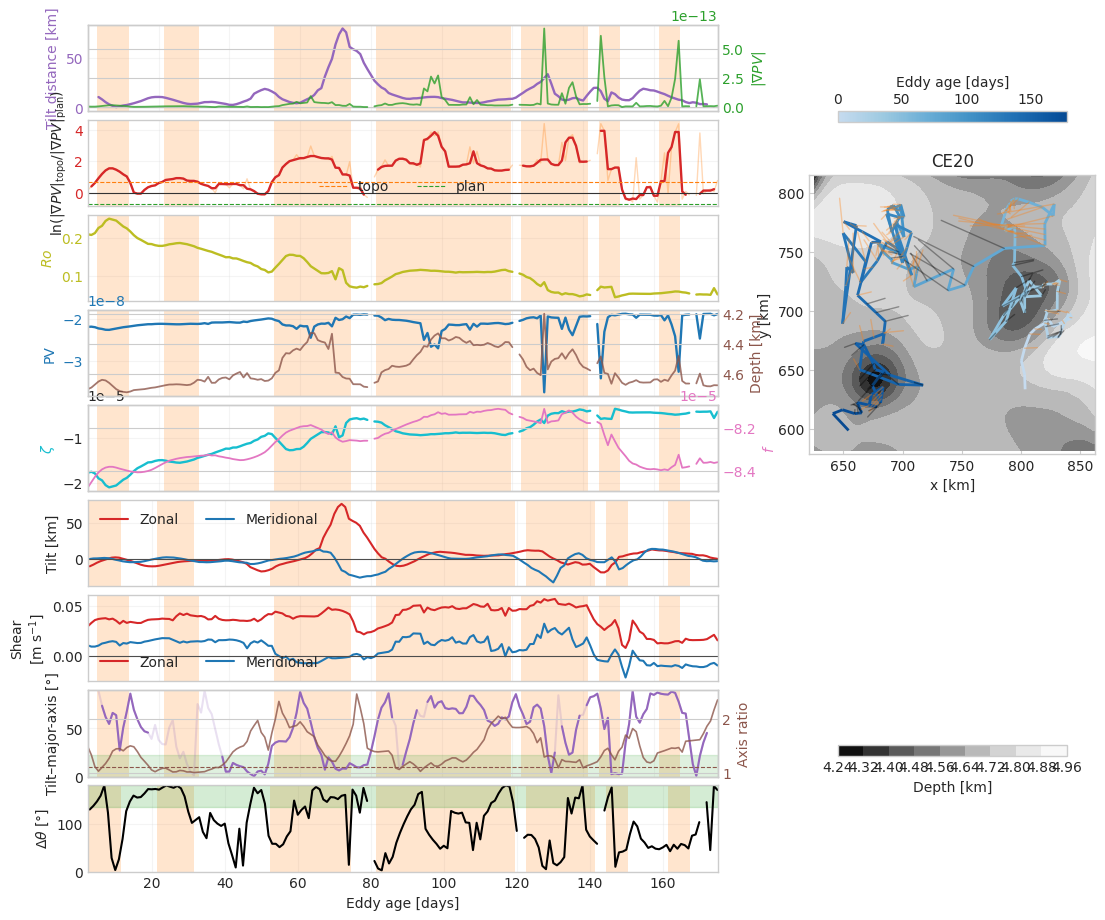

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


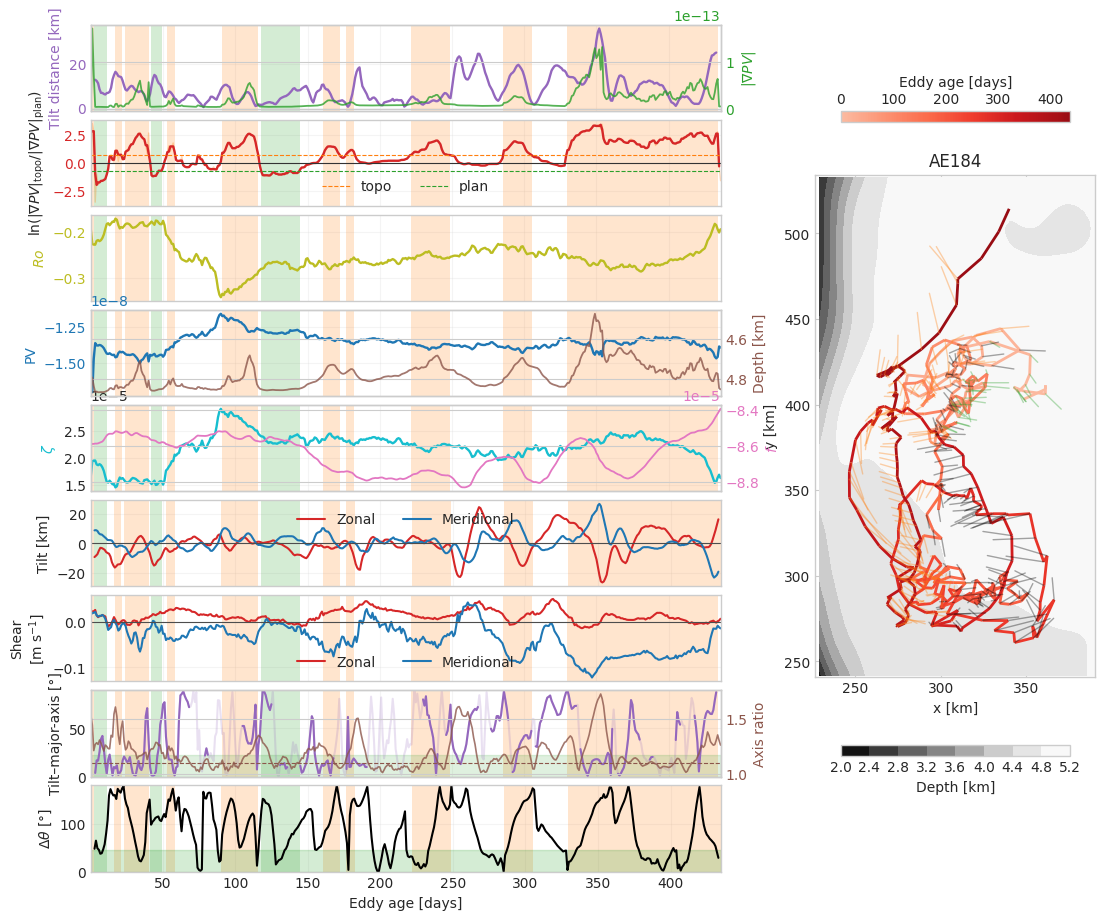

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


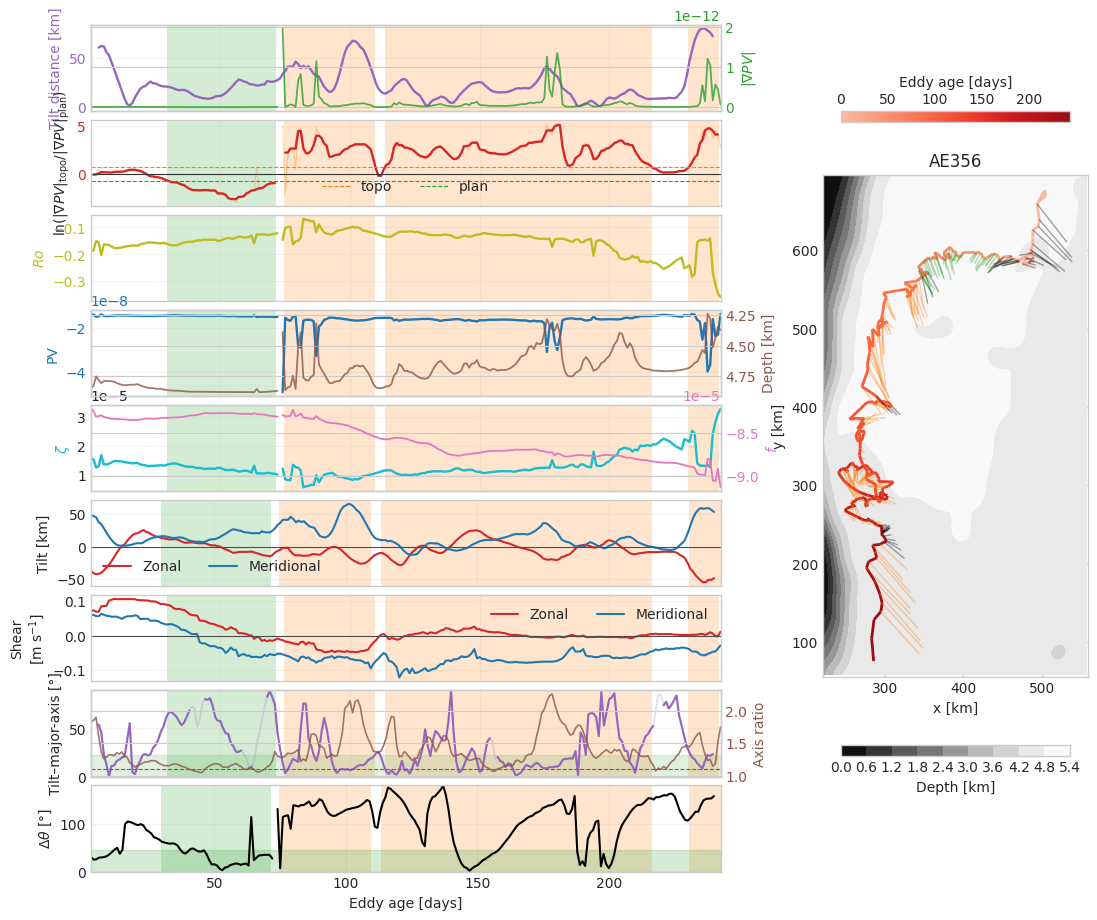

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


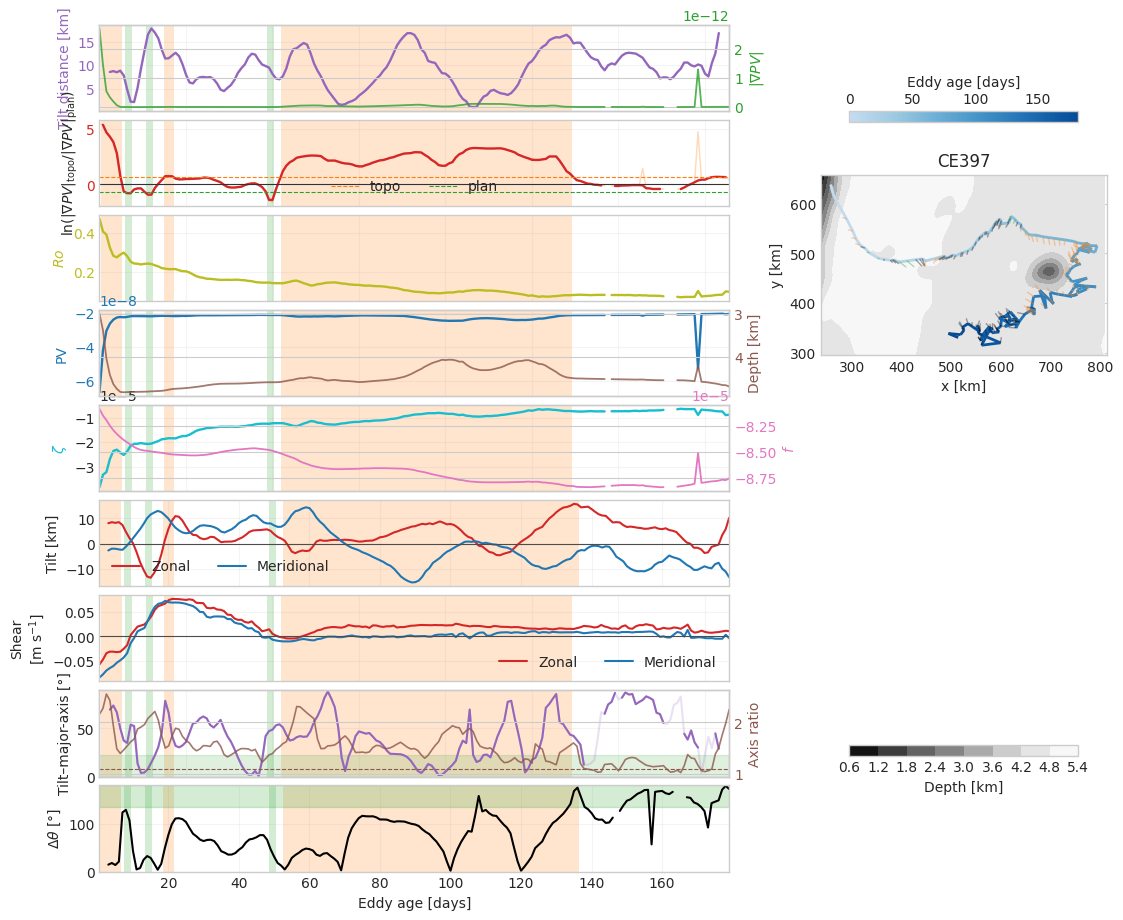

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


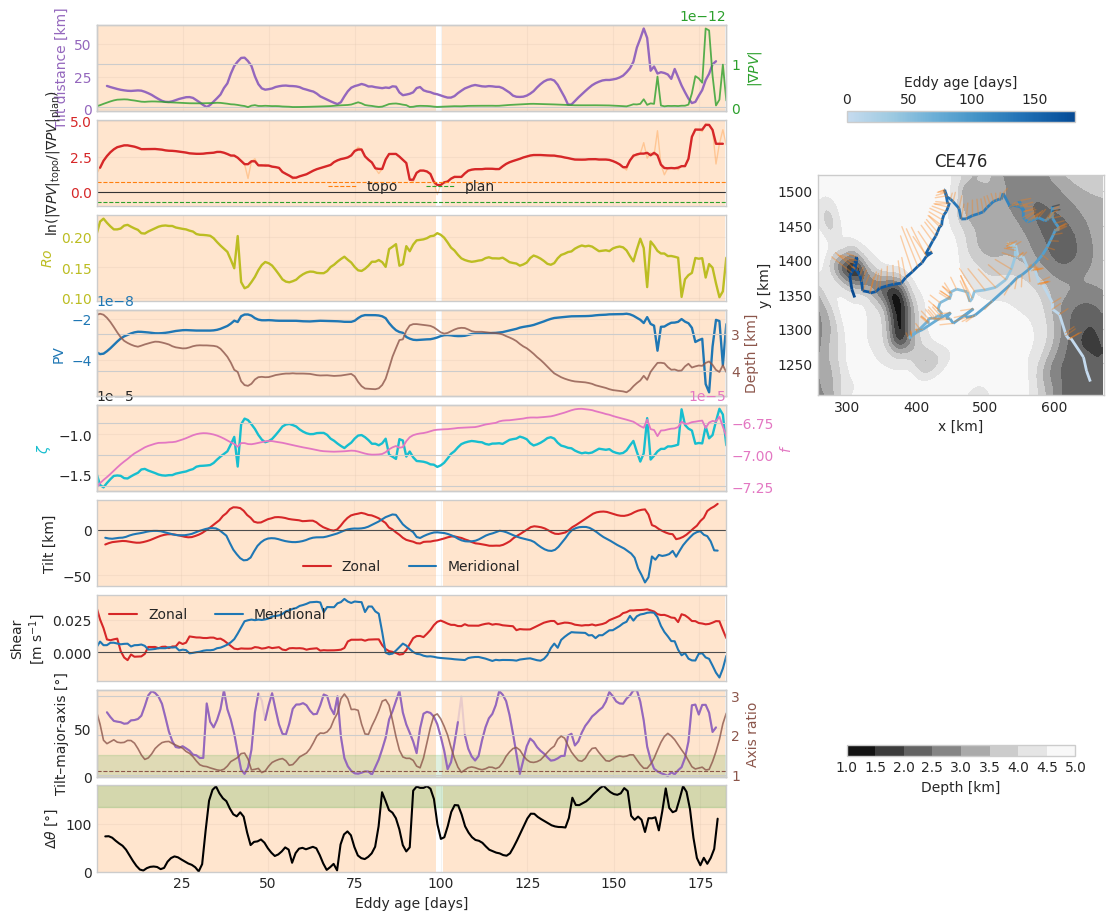

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


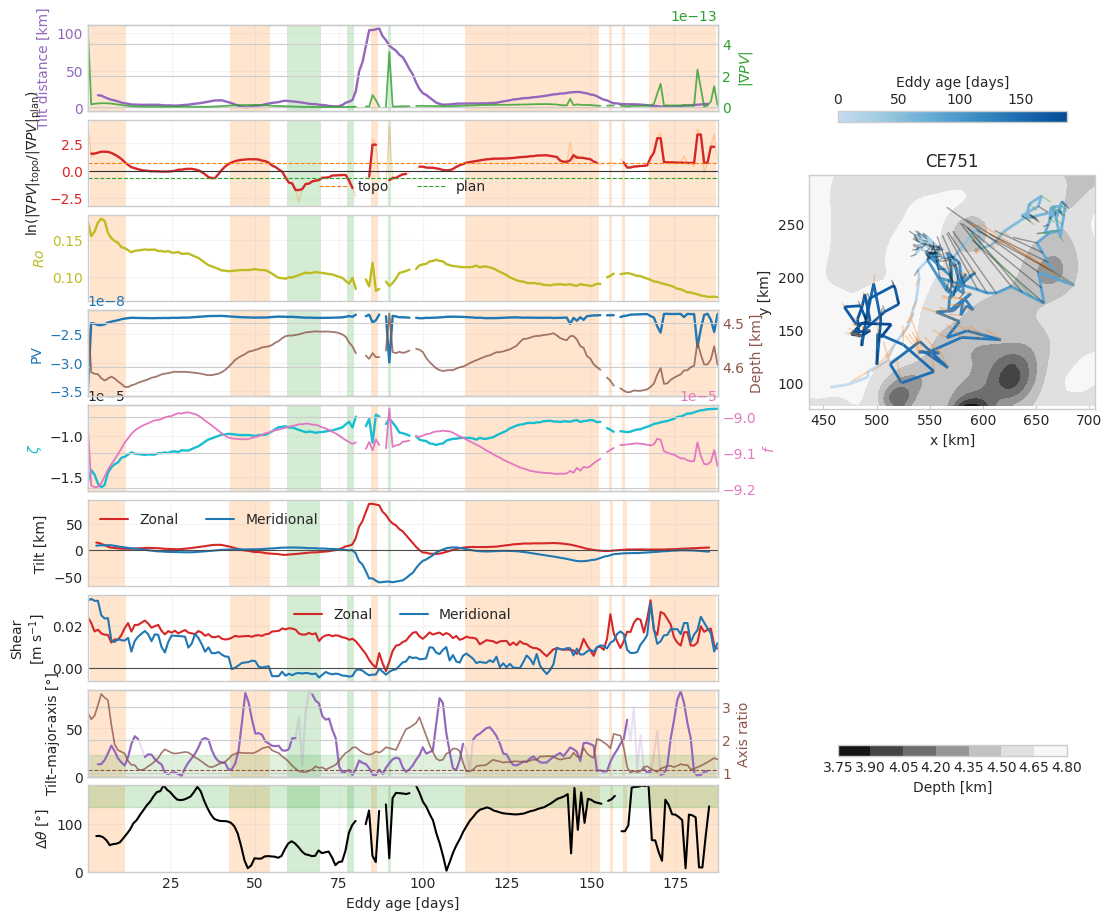

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


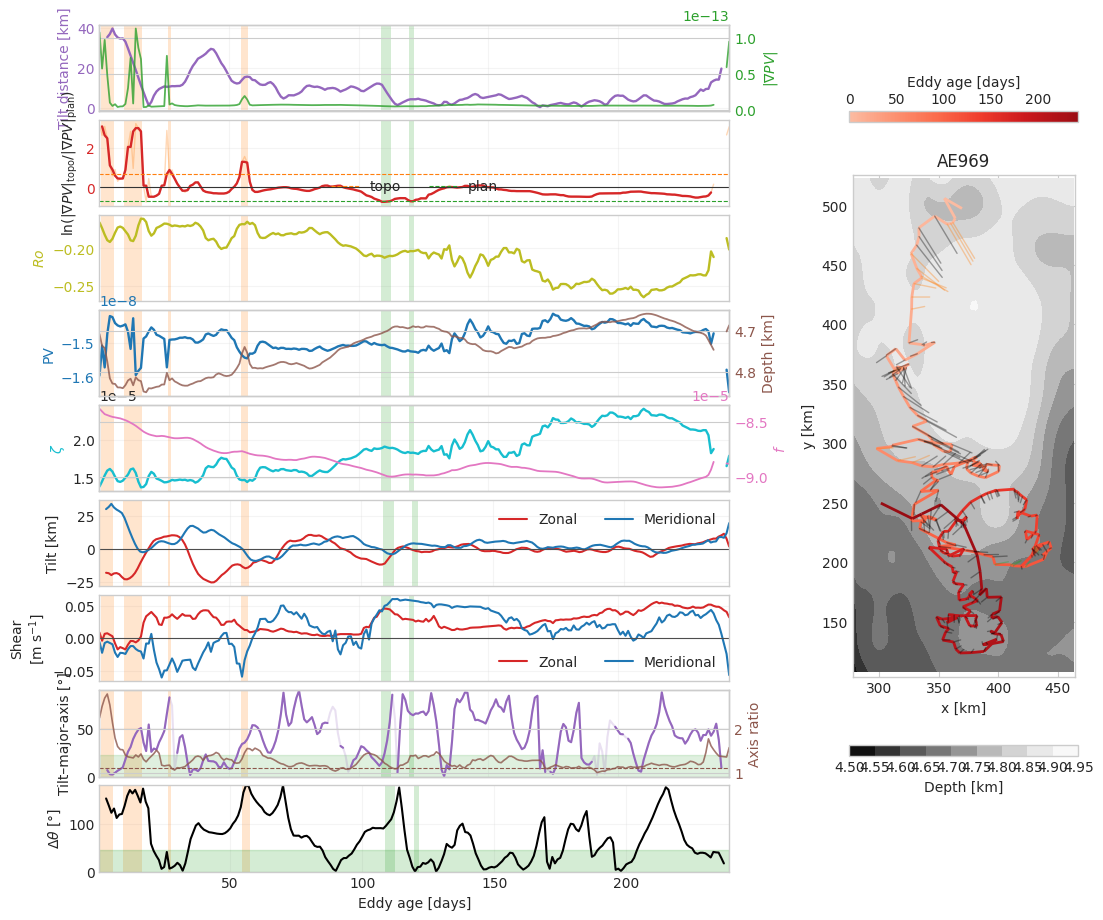

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


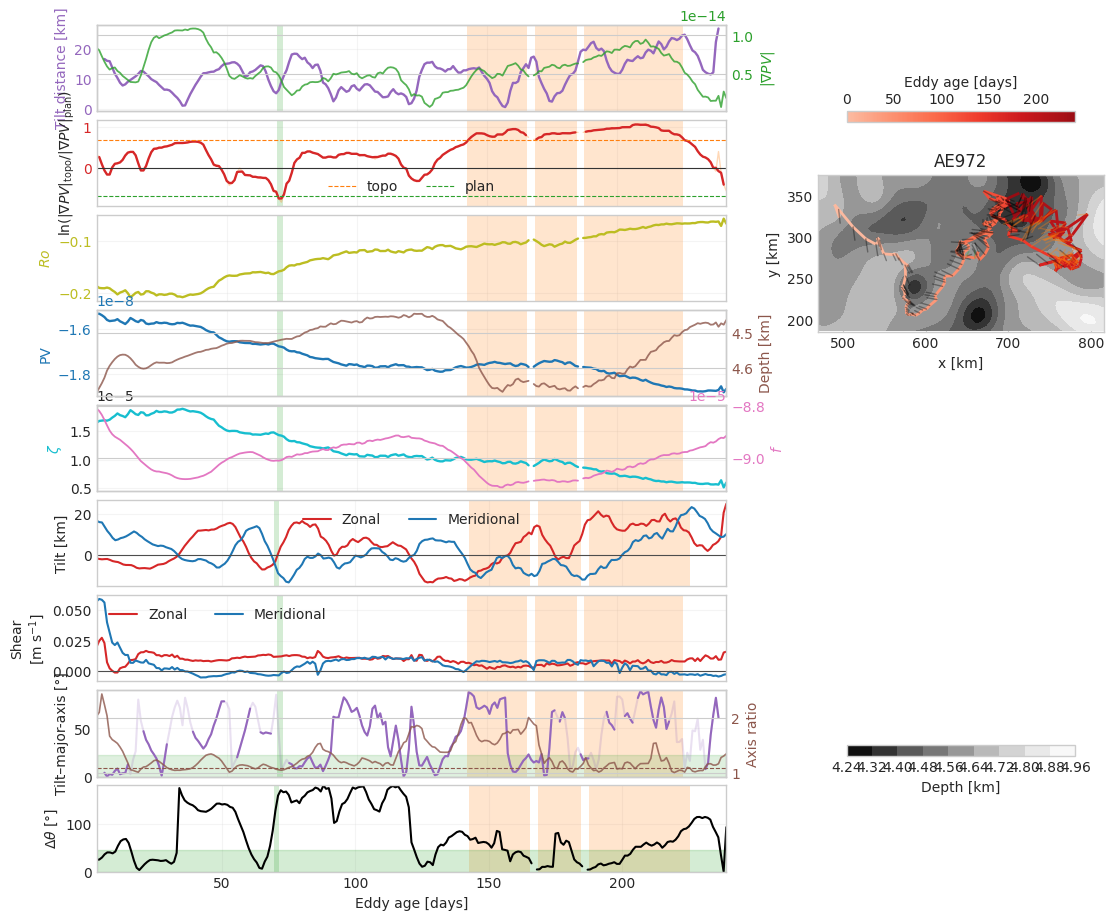

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


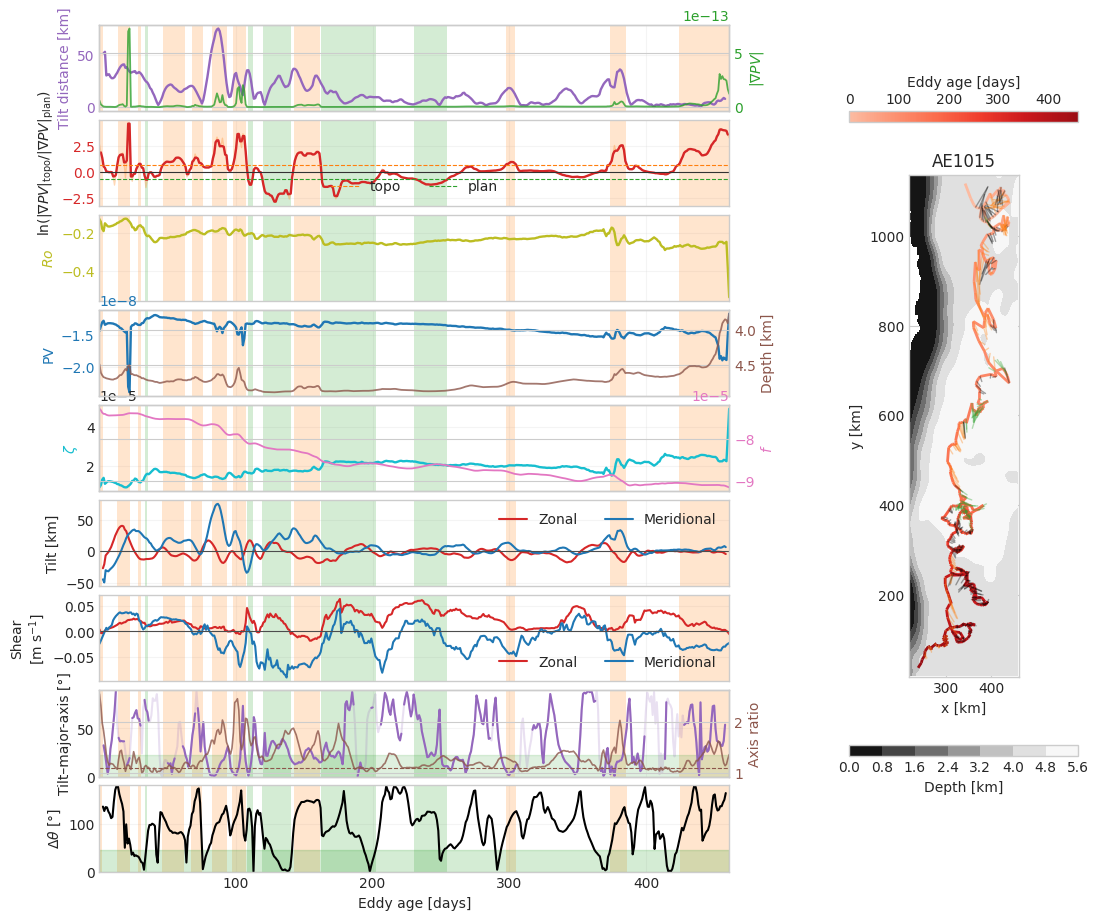

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


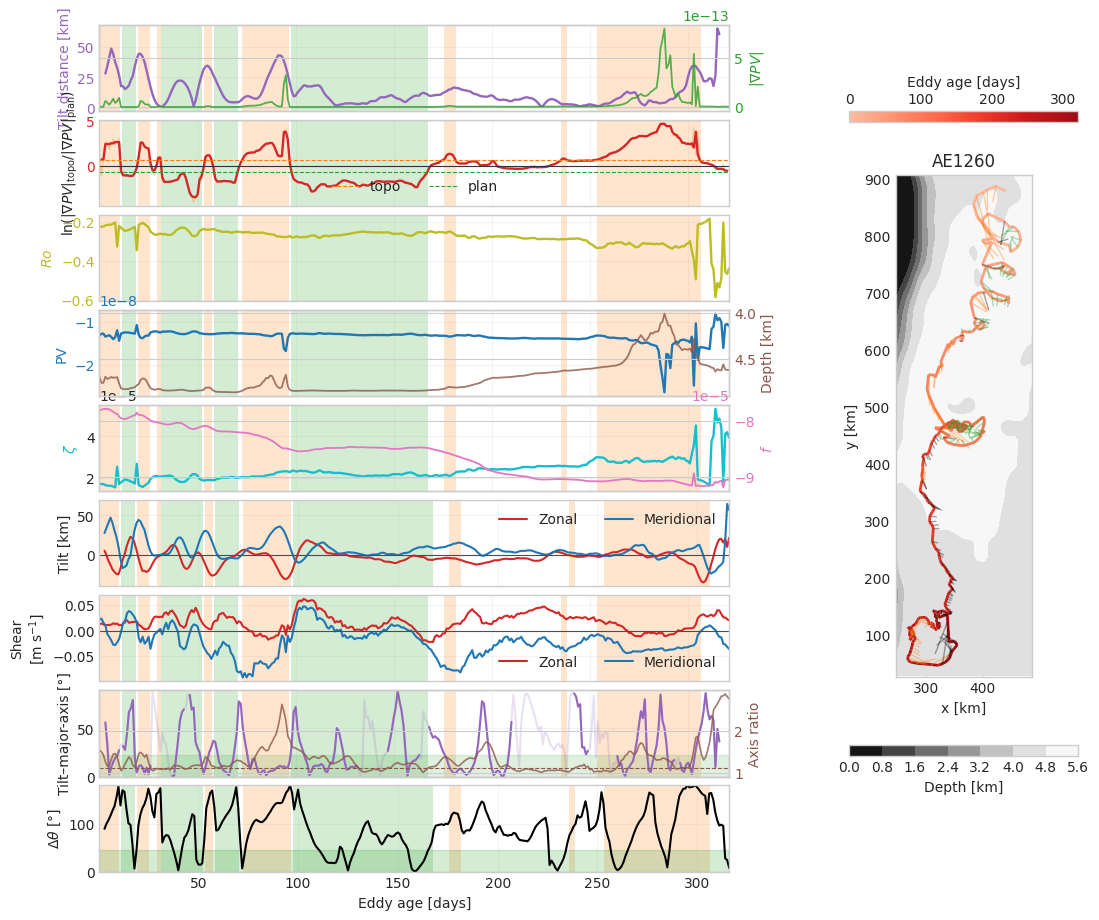

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


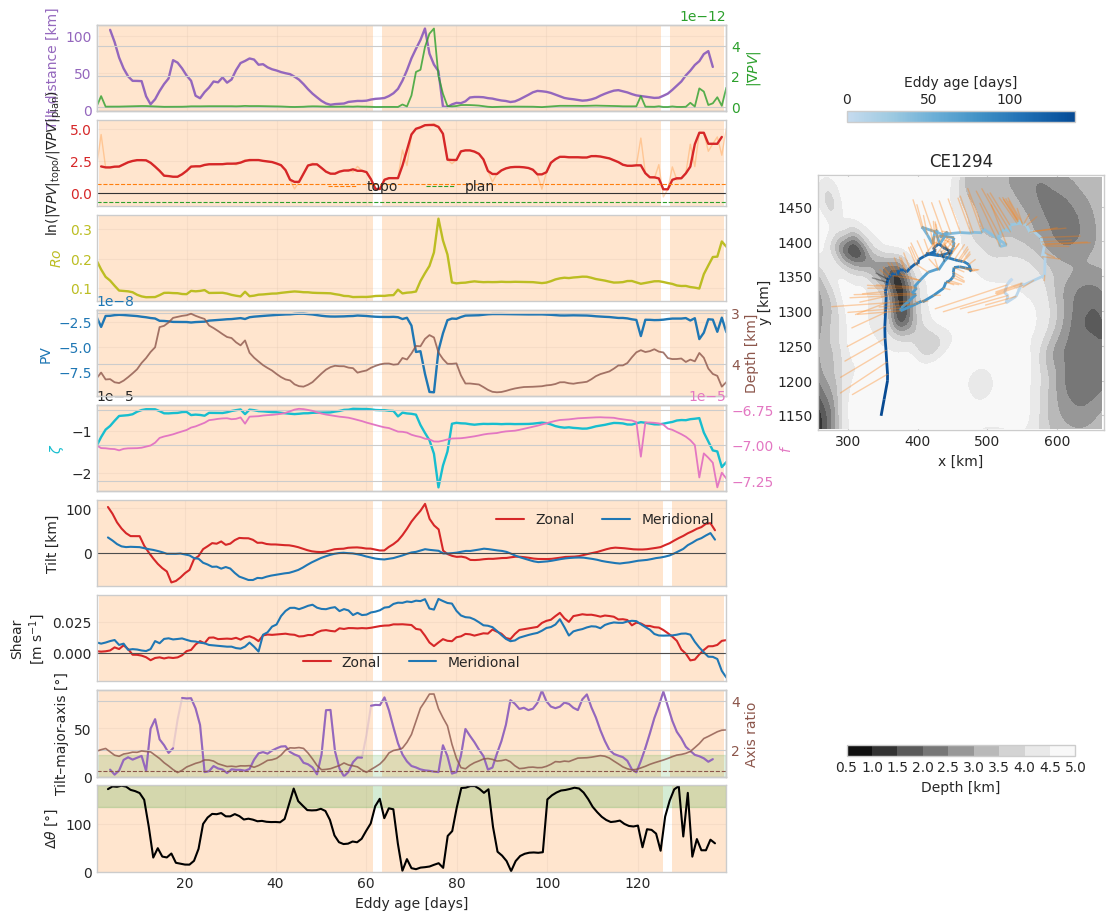

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


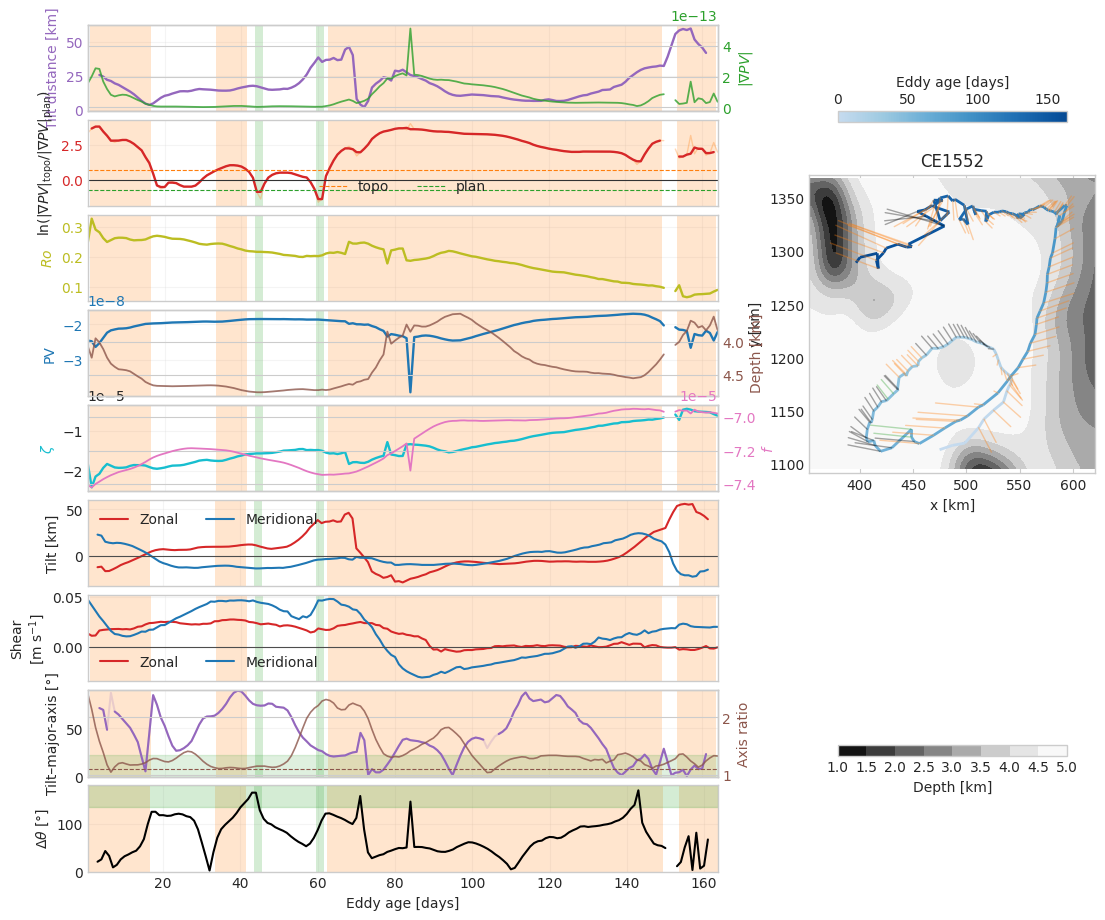

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


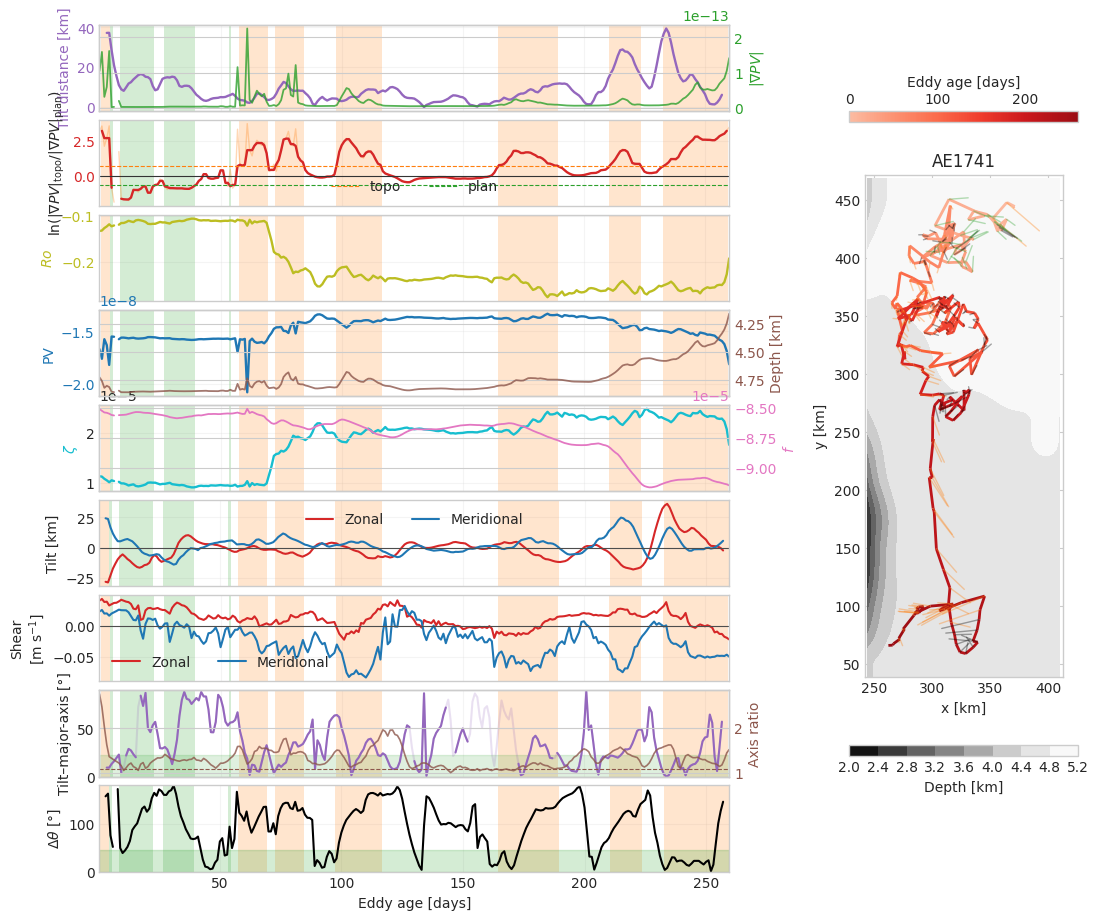

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


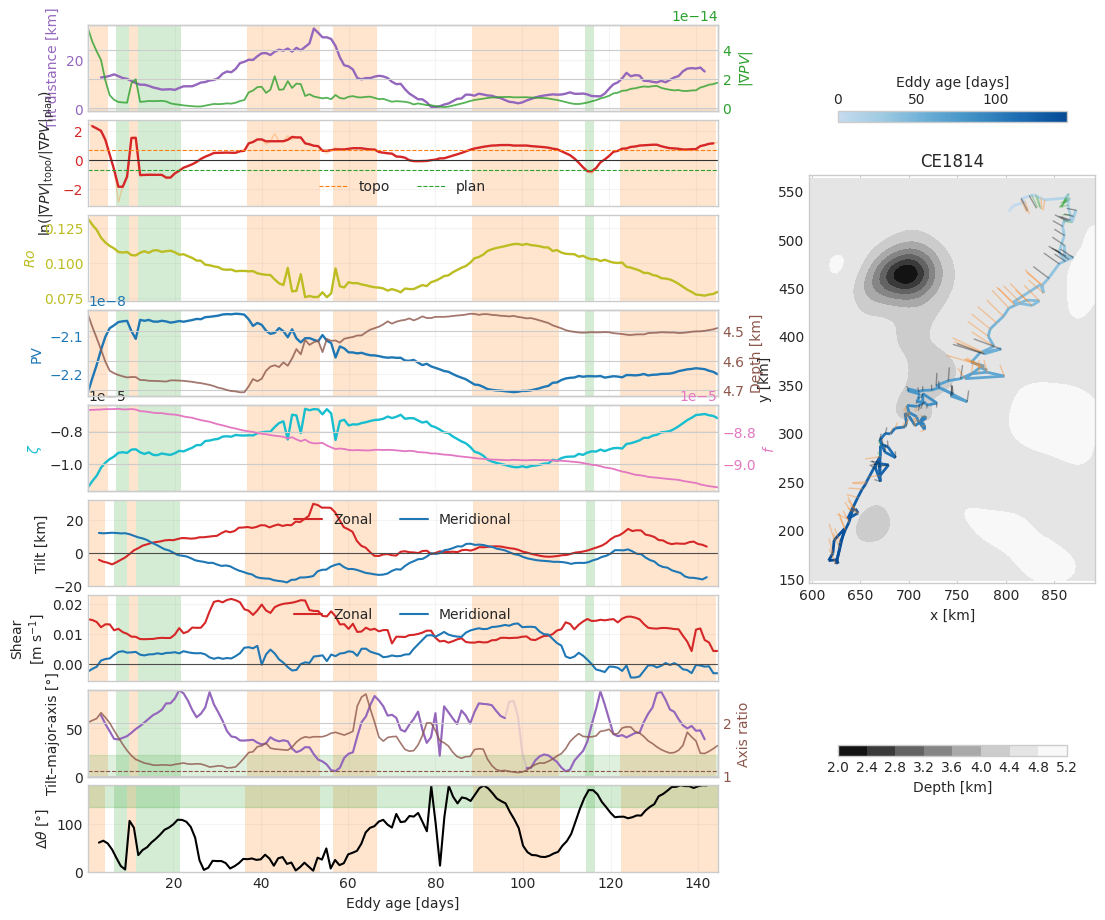

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


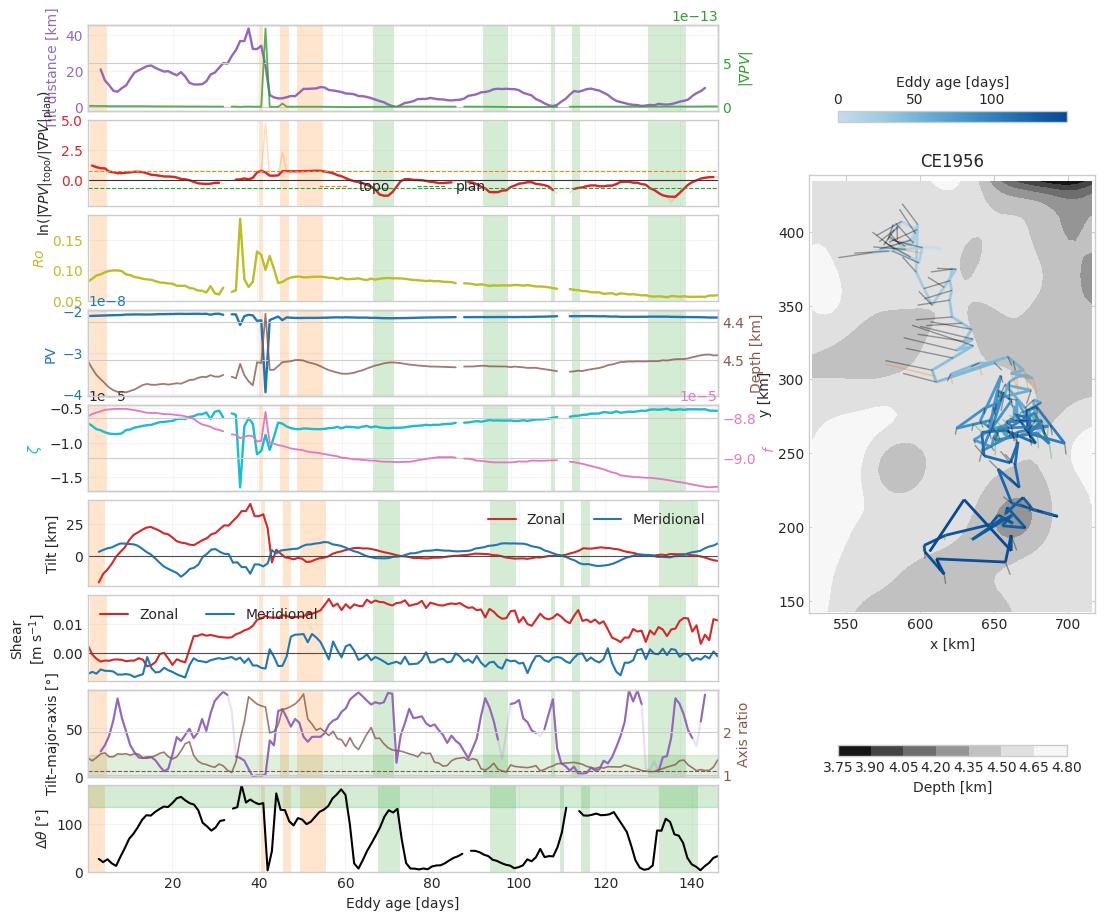

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


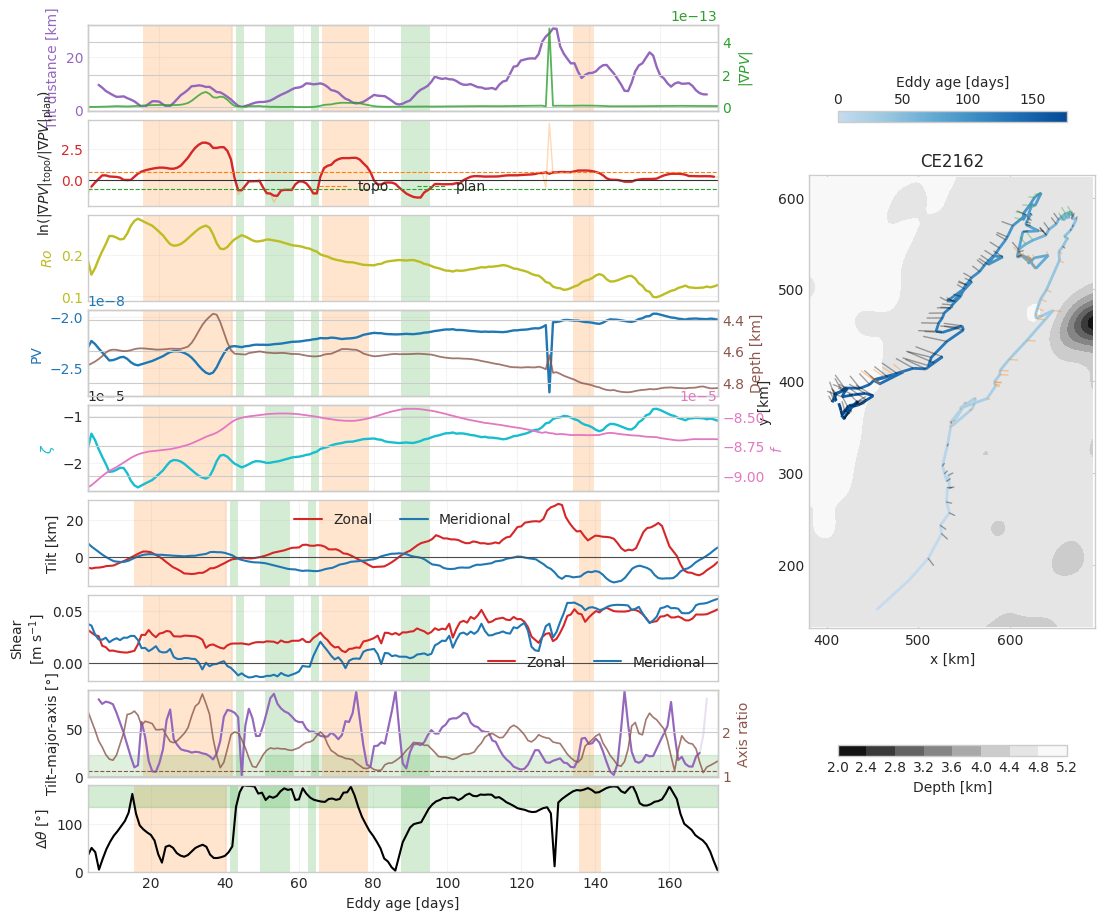

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


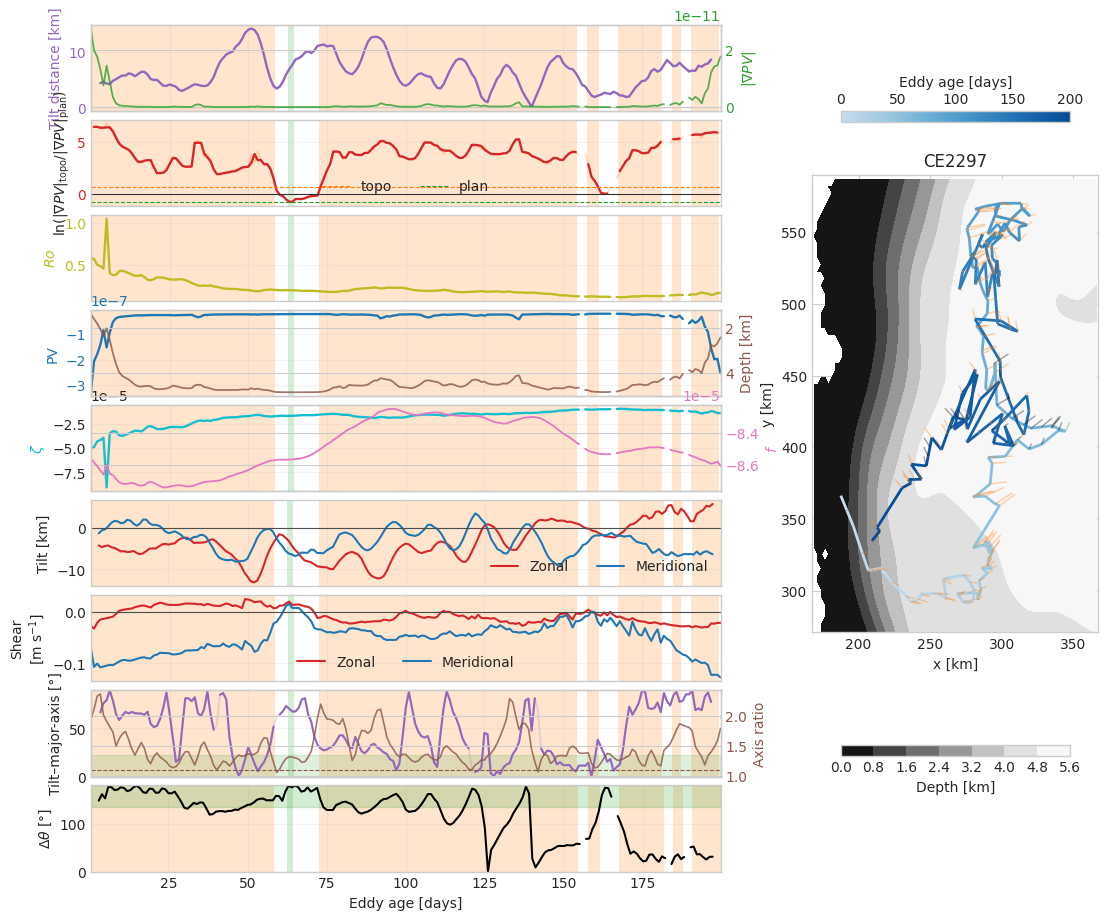

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


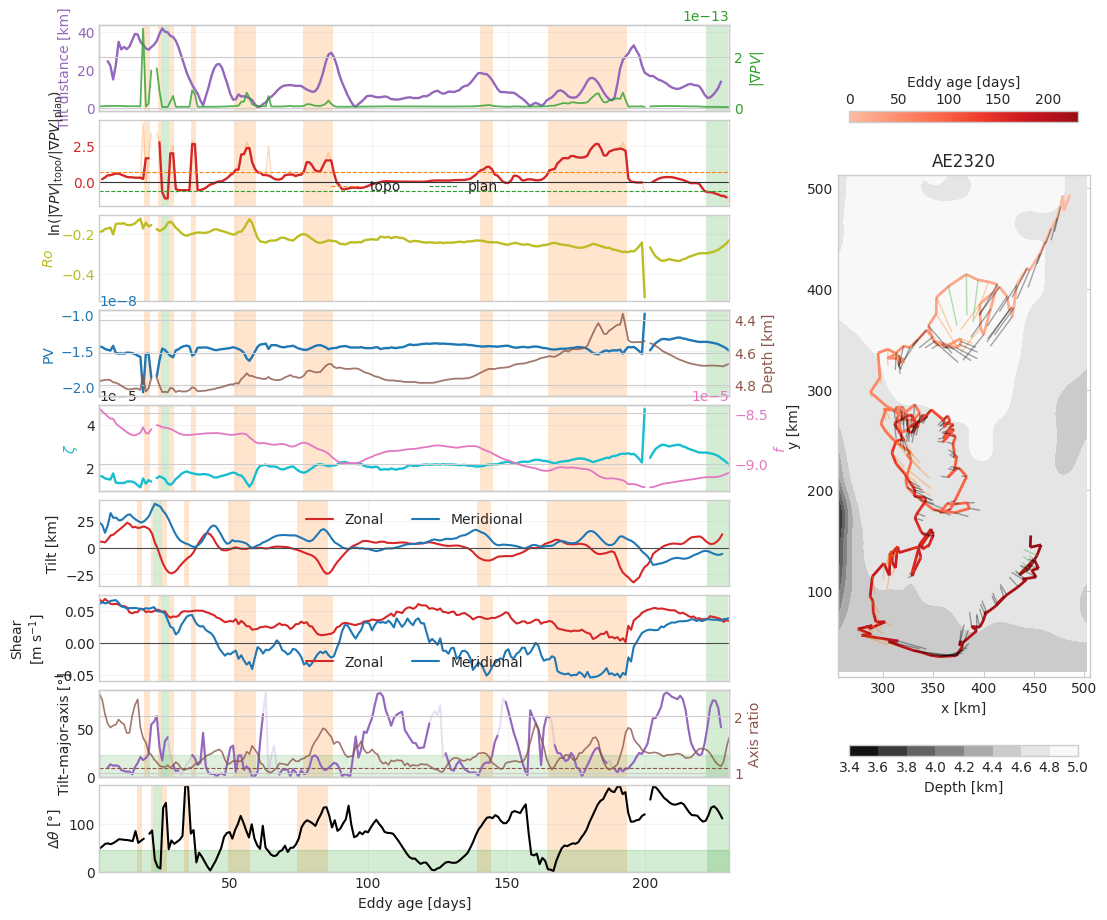

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_700944/2124499035.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


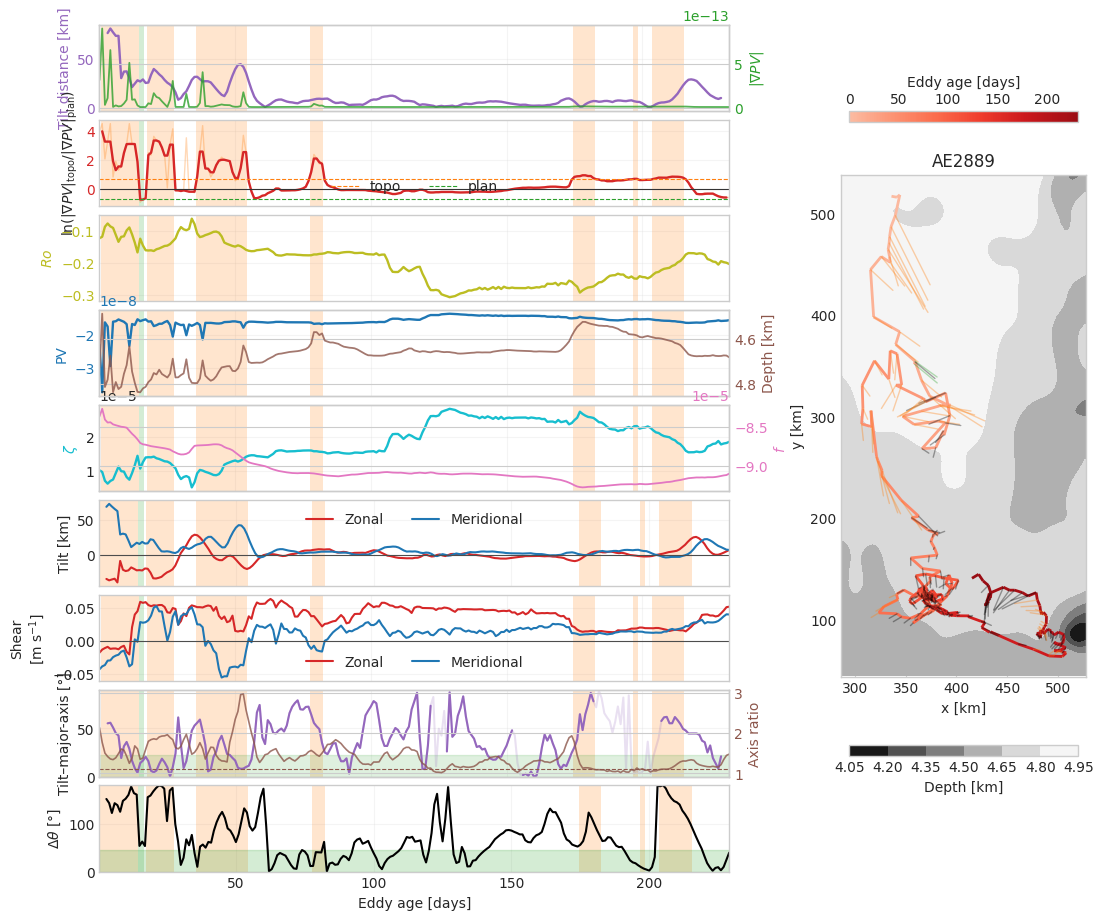

In [6]:
for eddy in df_old.Eddy.unique():
    time_plot(eddy, df_old, grid, figsize=(13,11), hspace=0.1)
    